In [81]:
import ee
import geemap
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
from pathlib import Path
import time

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

DATA_DIR = Path("Data/CCN")
OUT_DIR = Path("outputs")
OUT_DIR.mkdir(exist_ok=True)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {DEVICE}")

DEPTH_TARGETS = [0, 30, 100]

# lower/eastern coast
REGION_BBOX = {
    "lat_min": 24.5,
    "lat_max": 35.0,
    "lon_min": -98.0,
    "lon_max": -75.0,
}
print(f"Study region: US Lower Coast"
      f"({REGION_BBOX['lat_min']}–{REGION_BBOX['lat_max']} N, "
      f"{REGION_BBOX['lon_min']}–{REGION_BBOX['lon_max']} W)")

N_PCA_COMPONENTS = 30
MIN_SAMPLES = 20

Using device: cpu
Study region: US Gulf & Atlantic Coast (24.5–35.0°N, -98.0–-75.0°W)


## Loading CCN Locally

In [82]:
cores = pd.read_csv(DATA_DIR / "CCN_cores.csv", low_memory=False)
depthseries = pd.read_csv(DATA_DIR / "CCN_depthseries.csv", low_memory=False)

print(f"Cores: {cores.shape[0]:,} rows, Depthseries: {depthseries.shape[0]:,} rows")

Cores: 16,715 rows, Depthseries: 117,518 rows


In [83]:
core_locs = cores[["study_id", "site_id", "core_id", "latitude", "longitude", "habitat", "salinity_class", "vegetation_class"]].copy()

core_locs = core_locs[
    (core_locs["latitude"]  >= REGION_BBOX["lat_min"])
    & (core_locs["latitude"]  <= REGION_BBOX["lat_max"])
    & (core_locs["longitude"] >= REGION_BBOX["lon_min"])
    & (core_locs["longitude"] <= REGION_BBOX["lon_max"])
].copy()
print(f"Cores within bbox: {len(core_locs):,}")


def extract_carbon_at_depth(depthseries: pd.DataFrame, depth_min: int) -> pd.DataFrame:
    """Extract mean fraction_carbon for cores at a given depth_min."""
    layer = depthseries[depthseries["depth_min"] == depth_min].copy()
    layer = layer[layer["fraction_carbon"].notna()]
    agg = (
        layer.groupby(["study_id", "site_id", "core_id"])
        .agg(fraction_carbon=("fraction_carbon", "mean"))
        .reset_index()
    )
    merged = agg.merge(core_locs, on=["study_id", "site_id", "core_id"])
    merged = merged.dropna(subset=["latitude", "longitude"])
    merged = merged[(merged["fraction_carbon"] > 0) & (merged["fraction_carbon"] <= 1.0)]
    return merged


# datasets for each depth
depth_datasets = {}
for d in DEPTH_TARGETS:
    df = extract_carbon_at_depth(depthseries, d)
    depth_datasets[d] = df
    print(f"depth_min={d:3d} cm: {len(df):,} cores | "
          f"carbon {df['fraction_carbon'].min():.4f}–{df['fraction_carbon'].max():.4f} "
          f"(mean {df['fraction_carbon'].mean():.4f})")

Cores within study region bbox: 3,564
depth_min=  0 cm: 607 cores | carbon 0.0006–0.4711 (mean 0.1485)
depth_min= 30 cm: 162 cores | carbon 0.0036–0.4988 (mean 0.1276)
depth_min=100 cm: 19 cores | carbon 0.0253–0.3475 (mean 0.1471)


In [84]:
all_labeled = pd.concat(depth_datasets.values(), ignore_index=True)
unique_cores = all_labeled.drop_duplicates(subset=["study_id", "site_id", "core_id"])
print(f"Unique core locations to extract: {len(unique_cores):,}")

Unique core locations to extract: 621


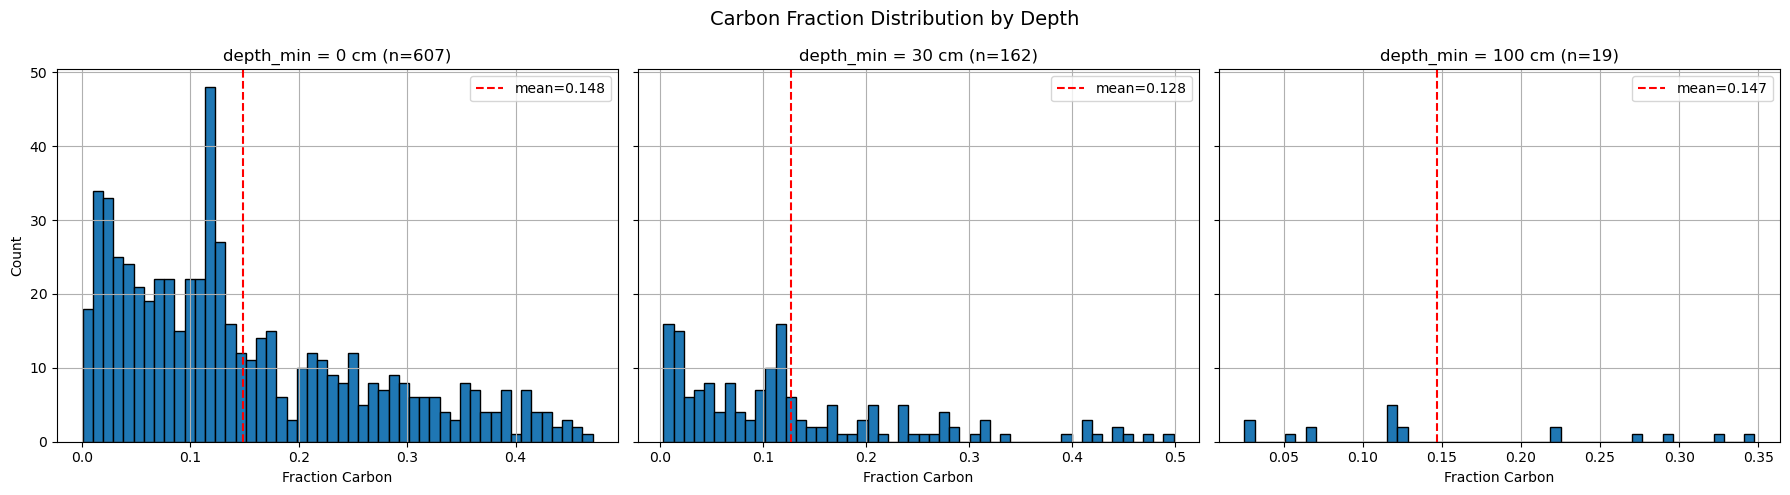

In [85]:
# carbon across depths
fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)

for ax, d in zip(axes, DEPTH_TARGETS):
    df = depth_datasets[d]
    df["fraction_carbon"].hist(bins=50, ax=ax, edgecolor="black")
    ax.set_xlabel("Fraction Carbon")
    ax.set_title(f"depth_min = {d} cm (n={len(df):,})")
    ax.axvline(df["fraction_carbon"].mean(), color="red", linestyle="--",
               label=f"mean={df['fraction_carbon'].mean():.3f}")
    ax.legend()

axes[0].set_ylabel("Count")
fig.suptitle("Carbon Fraction Distribution by Depth", fontsize=14)
plt.tight_layout()
plt.show()

## Get EMIT data at CCN locations

In [86]:
ee.Authenticate()
GEE_PROJECT = "nasa-eo-ccn"
ee.Initialize(project=GEE_PROJECT)

In [87]:
sites_gdf = gpd.GeoDataFrame(
    unique_cores,
    geometry=gpd.points_from_xy(unique_cores.longitude, unique_cores.latitude),
    crs="EPSG:4326",
)

ROI = ee.Geometry.Rectangle(
    [REGION_BBOX["lon_min"], REGION_BBOX["lat_min"],
     REGION_BBOX["lon_max"], REGION_BBOX["lat_max"]]
)


def gdf_to_ee_fc(gdf: gpd.GeoDataFrame) -> ee.FeatureCollection:
    """Convert a GeoDataFrame of points to an ee.FeatureCollection."""
    features = []
    for _, row in gdf.iterrows():
        geom = ee.Geometry.Point([row.geometry.x, row.geometry.y])
        props = {
            "core_id": str(row["core_id"]),
            "site_id": str(row["site_id"]),
            "study_id": str(row["study_id"]),
        }
        features.append(ee.Feature(geom, props))
    return ee.FeatureCollection(features)


BATCH_SIZE = 2000
n_total = len(sites_gdf)
print(f"Total sites to extract: {n_total:,}")
print(f"Batches needed: {int(np.ceil(n_total / BATCH_SIZE))}")

Total sites to extract: 621
Batches needed: 1


In [88]:
EMIT_COLLECTION = "NASA/EMIT/L2A/RFL"
DATE_START = "2023-01-01"
DATE_END = "2025-01-01"

emit_col = (
    ee.ImageCollection(EMIT_COLLECTION)
    .filterDate(DATE_START, DATE_END)
    .filterBounds(ROI)
)

def mask_emit_clouds(img: ee.Image) -> ee.Image:
    cloud_mask = img.select("dilated_cloud_flag").eq(0)
    return img.updateMask(cloud_mask)

emit_mosaic = emit_col.map(mask_emit_clouds).mosaic()

try:
    n_images = emit_col.size().getInfo()
    band_names = emit_mosaic.bandNames().getInfo()
    print(f"EMIT scenes: {n_images}, Bands in mosaic: {len(band_names)}")
except Exception as e:
    print(f"Info call failed (non-critical): {e}")
    print("Continuing — mosaic is defined lazily and will be computed during extraction.")

EMIT scenes: 1740, Bands in mosaic: 579


In [89]:
CACHE_FILE = OUT_DIR / "emit_ccn_raw_extraction.csv"
MAX_RETRIES = 3
RETRY_DELAY = 30

if CACHE_FILE.exists():
    # reload last extract
    spectra_df = pd.read_csv(CACHE_FILE)
    print(f"Loaded cached extraction: {len(spectra_df):,} rows from {CACHE_FILE}")
else:
    all_points_fc = gdf_to_ee_fc(sites_gdf)
    all_sampled = []

    for i in range(0, n_total, BATCH_SIZE):
        batch_gdf = sites_gdf.iloc[i : i + BATCH_SIZE]
        batch_fc = gdf_to_ee_fc(batch_gdf)
        batch_num = i // BATCH_SIZE + 1

        sampled_fc = emit_mosaic.sampleRegions(
            collection=batch_fc,
            scale=60,
            geometries=True,
            tileScale=4,
        )

        for attempt in range(1, MAX_RETRIES + 1):
            try:
                batch_df = geemap.ee_to_df(sampled_fc)
                break
            except Exception as e:
                print(f"  Batch {batch_num} attempt {attempt}/{MAX_RETRIES} failed: {e}")
                if attempt < MAX_RETRIES:
                    print(f"  Retrying in {RETRY_DELAY}s...")
                    time.sleep(RETRY_DELAY)
                else:
                    raise RuntimeError(
                        f"Batch {batch_num} failed after {MAX_RETRIES} attempts. "
                    )

        all_sampled.append(batch_df)
        print(f"Batch {batch_num}: extracted {len(batch_df)} samples")

    spectra_df = pd.concat(all_sampled, ignore_index=True)
    spectra_df.to_csv(CACHE_FILE, index=False)
    print(f"\nTotal extracted spectra: {len(spectra_df):,} — saved to {CACHE_FILE}")

Loaded cached extraction: 571 rows from outputs\emit_ccn_raw_extraction.csv


In [91]:
# keep only numbered reflectance bands
refl_cols = sorted(
    [c for c in spectra_df.columns
     if c.startswith("reflectance_") and c.split("_")[1].isdigit()],
    key=lambda x: int(x.split("_")[1]),
)
n_bands = len(refl_cols)
wavelengths = np.linspace(381, 2493, n_bands)

keep_mask = ~(
    ((wavelengths >= 1350) & (wavelengths <= 1450))
    | ((wavelengths >= 1800) & (wavelengths <= 1950))
)
keep_cols = [refl_cols[i] for i in range(n_bands) if keep_mask[i]]

print(f"Total bands: {n_bands}, Kept: {len(keep_cols)}, "
      f"Removed: {n_bands - len(keep_cols)}")

Total bands: 285, Kept: 252, Removed: 33 water-absorption bands


In [92]:
from scipy.signal import savgol_filter
from sklearn.base import BaseEstimator, RegressorMixin
from sklearn.linear_model import RidgeCV
from sklearn.ensemble import (
    RandomForestRegressor, GradientBoostingRegressor, StackingRegressor
)
from sklearn.model_selection import RepeatedKFold, cross_validate
from sklearn.pipeline import Pipeline
import warnings
warnings.filterwarnings("ignore", category=UserWarning)

def compute_spectral_features(X_raw, wavelengths_kept):
    """Augment raw reflectance with first derivative and spectral indices. Returns (X_augmented, feature_names).
    """
    n_samples, n_bands = X_raw.shape

    # Savitzky–Golay first derivative
    window = min(11, n_bands if n_bands % 2 == 1 else n_bands - 1)
    X_deriv = savgol_filter(X_raw, window_length=window, polyorder=2, deriv=1, axis=1)

    # Continuum-removed depth at key absorption regions
    # ~480nm (chlorophyll), ~670nm (chlorophyll-b), ~2200nm (clay/organic)
    indices = {}
    for target_nm, name in [(480, "blue_abs"), (670, "red_abs"), (2200, "swir_abs")]:
        idx = np.argmin(np.abs(wavelengths_kept - target_nm))
        left = max(0, idx - 3)
        right = min(n_bands - 1, idx + 3)
        continuum = (X_raw[:, left] + X_raw[:, right]) / 2.0
        depth = 1.0 - X_raw[:, idx] / np.where(continuum > 0, continuum, 1e-8)
        indices[name] = depth
        
    nir_idx = np.argmin(np.abs(wavelengths_kept - 850))
    red_idx = np.argmin(np.abs(wavelengths_kept - 670))
    nir = X_raw[:, nir_idx]
    red = X_raw[:, red_idx]
    indices["ndvi"] = (nir - red) / np.where((nir + red) > 0, nir + red, 1e-8)

    # mean reflectance in SWIR
    swir_mask = (wavelengths_kept >= 2000) & (wavelengths_kept <= 2400)
    if swir_mask.any():
        indices["swir_mean"] = X_raw[:, swir_mask].mean(axis=1)

    # spectral slope
    vis_mask = (wavelengths_kept >= 450) & (wavelengths_kept <= 700)
    if vis_mask.any() and swir_mask.any():
        indices["vis_swir_slope"] = (
            X_raw[:, swir_mask].mean(axis=1) - X_raw[:, vis_mask].mean(axis=1)
        )

    index_array = np.column_stack(list(indices.values()))
    X_aug = np.hstack([X_raw, X_deriv, index_array])

    feature_names = (
        [f"raw_{i}" for i in range(n_bands)]
        + [f"deriv_{i}" for i in range(n_bands)]
        + list(indices.keys())
    )
    return X_aug, feature_names

class SpectralCNN(nn.Module):
    """CNN that treats the spectrum as a 1D signal.
    """
    def __init__(self, n_input: int):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv1d(1, 32, kernel_size=5, padding=2),
            nn.BatchNorm1d(32),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Conv1d(32, 64, kernel_size=5, padding=4, dilation=2),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.AdaptiveAvgPool1d(8),
            nn.Dropout(0.2),
            nn.Conv1d(64, 32, kernel_size=3, padding=1),
            nn.BatchNorm1d(32),
            nn.ReLU(),
            nn.AdaptiveAvgPool1d(4),
        )
        self.regressor = nn.Sequential(
            nn.Flatten(),
            nn.Linear(32 * 4, 32),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(32, 1),
        )

    def forward(self, x):
        x = x.unsqueeze(1)
        x = self.features(x)
        return self.regressor(x)


class CNNRegressor(BaseEstimator, RegressorMixin):
    """Inherits from BaseEstimator + RegressorMixin so that StackingRegressor recognises it as a valid regressor.
    """

    def __init__(self, n_input=30, epochs=200, lr=1e-3, patience=25, batch_size=32):
        self.n_input = n_input
        self.epochs = epochs
        self.lr = lr
        self.patience = patience
        self.batch_size = batch_size
        self.model_ = None
        self.scaler_ = StandardScaler()

    def fit(self, X, y):
        X = self.scaler_.fit_transform(X)
        X_t = torch.tensor(X, dtype=torch.float32)
        y_t = torch.tensor(y, dtype=torch.float32).unsqueeze(1)

        n_val = max(1, int(0.15 * len(X)))
        idx = np.random.RandomState(42).permutation(len(X))
        train_idx, val_idx = idx[n_val:], idx[:n_val]

        train_ds = TensorDataset(X_t[train_idx], y_t[train_idx])
        val_ds = TensorDataset(X_t[val_idx], y_t[val_idx])
        train_loader = DataLoader(train_ds, batch_size=self.batch_size, shuffle=True)
        val_loader = DataLoader(val_ds, batch_size=self.batch_size)

        self.model_ = SpectralCNN(self.n_input).to(DEVICE)
        optimizer = torch.optim.Adam(self.model_.parameters(), lr=self.lr, weight_decay=1e-3)
        scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
            optimizer, mode="min", factor=0.5, patience=10
        )
        criterion = nn.MSELoss()

        best_val, best_state, patience_ctr = float("inf"), None, 0
        for epoch in range(1, self.epochs + 1):
            self.model_.train()
            for Xb, yb in train_loader:
                Xb, yb = Xb.to(DEVICE), yb.to(DEVICE)
                optimizer.zero_grad()
                criterion(self.model_(Xb), yb).backward()
                optimizer.step()

            self.model_.eval()
            val_loss = 0.0
            with torch.no_grad():
                for Xb, yb in val_loader:
                    Xb, yb = Xb.to(DEVICE), yb.to(DEVICE)
                    val_loss += criterion(self.model_(Xb), yb).item() * len(Xb)
            val_loss /= len(val_ds)
            scheduler.step(val_loss)

            if val_loss < best_val:
                best_val = val_loss
                patience_ctr = 0
                best_state = {k: v.cpu().clone() for k, v in self.model_.state_dict().items()}
            else:
                patience_ctr += 1
            if patience_ctr >= self.patience:
                break

        if best_state:
            self.model_.load_state_dict(best_state)
        return self

    def predict(self, X):
        X = self.scaler_.transform(X)
        X_t = torch.tensor(X, dtype=torch.float32).to(DEVICE)
        self.model_.eval()
        with torch.no_grad():
            return self.model_(X_t).cpu().numpy().flatten()


def prepare_data(spectra_df, carbon_df, keep_cols, wavelengths_kept,
                 n_pca=N_PCA_COMPONENTS, min_samples=MIN_SAMPLES):
    """Merge, engineer features, PCA-reduce, split. Returns dict or None if too few samples.
    """
    merged = spectra_df.merge(
        carbon_df[["study_id", "site_id", "core_id", "fraction_carbon"]],
        on=["study_id", "site_id", "core_id"],
    )

    X_raw = merged[keep_cols].copy()
    y = merged["fraction_carbon"].copy()

    valid = X_raw.notna().any(axis=1) & y.notna()
    X_raw = X_raw[valid].fillna(0.0).values
    y = y[valid].values

    if len(X_raw) < min_samples:
        return None

    # feature engineering
    X_aug, feat_names = compute_spectral_features(X_raw, wavelengths_kept)
    print(f"  Features: {X_raw.shape[1]} raw + {X_raw.shape[1]} deriv + "
          f"{X_aug.shape[1] - 2*X_raw.shape[1]} indices = {X_aug.shape[1]} total")

    # split
    X_train, X_test, y_train, y_test = train_test_split(
        X_aug, y, test_size=0.2, random_state=42
    )

    # scale and pca
    scaler = StandardScaler()
    X_train_s = scaler.fit_transform(X_train)
    X_test_s = scaler.transform(X_test)

    n_comp = min(n_pca, X_train_s.shape[0], X_train_s.shape[1])
    pca = PCA(n_components=n_comp)
    X_train_pca = pca.fit_transform(X_train_s)
    X_test_pca = pca.transform(X_test_s)
    print(f"  PCA: {n_comp} components → {pca.explained_variance_ratio_.sum():.1%} variance")

    return {
        "X_train": X_train_pca, "X_test": X_test_pca,
        "y_train": y_train, "y_test": y_test,
        "scaler": scaler, "pca": pca,
        "feat_names": feat_names,
    }


def build_ensemble(n_input):
    """Build ensemble of regressors."""
    estimators = [
        ("ridge", RidgeCV(alphas=np.logspace(-3, 3, 20))),
        ("rf", RandomForestRegressor(
            n_estimators=500, max_depth=10, min_samples_leaf=5,
            max_features="sqrt", random_state=42, n_jobs=-1,
        )),
        ("gbr", GradientBoostingRegressor(
            n_estimators=300, max_depth=4, learning_rate=0.05,
            subsample=0.8, min_samples_leaf=5, random_state=42,
        )),
        ("cnn", CNNRegressor(n_input=n_input, epochs=200, patience=25)),
    ]

    stack = StackingRegressor(
        estimators=estimators,
        final_estimator=RidgeCV(alphas=np.logspace(-2, 2, 10)),
        cv=5,
        n_jobs=1,
    )
    return stack, estimators


print("Model infrastructure ready.")

Model infrastructure ready.


## Train and evaluate for each depth

In [93]:
wavelengths_kept = wavelengths[keep_mask]
results = {}

for depth in DEPTH_TARGETS:
    label = f"{depth}cm"
    print(f"\n{'='*60}")
    print(f"DEPTH TARGET: {depth} cm")
    print(f"{'='*60}")

    data = prepare_data(spectra_df, depth_datasets[depth], keep_cols, wavelengths_kept)
    if data is None:
        print(f"  Skipping {label}: too few samples (need >= {MIN_SAMPLES}).")
        continue

    X_train, X_test = data["X_train"], data["X_test"]
    y_train, y_test = data["y_train"], data["y_test"]
    n_input = X_train.shape[1]
    print(f"  Train: {len(X_train):,}  Test: {len(X_test):,}")

    # CV scores
    print(f"\nCross-validated base model scores:")
    cv = RepeatedKFold(n_splits=5, n_repeats=2, random_state=42)

    base_models = {
        "Ridge": RidgeCV(alphas=np.logspace(-3, 3, 20)),
        "Random Forest": RandomForestRegressor(
            n_estimators=500, max_depth=10, min_samples_leaf=5,
            max_features="sqrt", random_state=42, n_jobs=-1,
        ),
        "Gradient Boosting": GradientBoostingRegressor(
            n_estimators=300, max_depth=4, learning_rate=0.05,
            subsample=0.8, min_samples_leaf=5, random_state=42,
        ),
    }

    cv_results = {}
    for name, model in base_models.items():
        scores = cross_validate(
            model, X_train, y_train, cv=cv,
            scoring=["r2", "neg_mean_absolute_error", "neg_root_mean_squared_error"],
            return_train_score=False, n_jobs=-1,
        )
        r2_mean = scores["test_r2"].mean()
        r2_std = scores["test_r2"].std()
        mae_mean = -scores["test_neg_mean_absolute_error"].mean()
        rmse_mean = -scores["test_neg_root_mean_squared_error"].mean()
        cv_results[name] = {"r2": r2_mean, "r2_std": r2_std, "mae": mae_mean, "rmse": rmse_mean}
        print(f"  {name:20s}: R²={r2_mean:.4f} ± {r2_std:.4f}  "f"MAE={mae_mean:.4f}  RMSE={rmse_mean:.4f}")

    # CNN
    print(f"{'1D-CNN':20s}: (training)")

    # fit ensemble on train
    print(f"\nFitting ensemble:")
    stack, _ = build_ensemble(n_input)
    stack.fit(X_train, y_train)

    # evaluation
    y_pred_stack = stack.predict(X_test)
    test_results = {
        "Ensemble (Stack)": {
            "y_pred": y_pred_stack,
            "r2": r2_score(y_test, y_pred_stack),
            "mae": mean_absolute_error(y_test, y_pred_stack),
            "rmse": np.sqrt(mean_squared_error(y_test, y_pred_stack)),
        }
    }

    # individual test predictions
    for name, estimator in stack.named_estimators_.items():
        y_pred_i = estimator.predict(X_test)
        test_results[name] = {
            "y_pred": y_pred_i,
            "r2": r2_score(y_test, y_pred_i),
            "mae": mean_absolute_error(y_test, y_pred_i),
            "rmse": np.sqrt(mean_squared_error(y_test, y_pred_i)),
        }

    print(f"\nTest set results:")
    for name, m in test_results.items():
        marker = "*" if name == "Ensemble (Stack)" else ""
        print(f"  {name:20s}: R²={m['r2']:.4f}  MAE={m['mae']:.4f}  RMSE={m['rmse']:.4f}{marker}")

    results[depth] = {
        "test_results": test_results,
        "cv_results": cv_results,
        "y_test": y_test,
        "stack": stack,
        "scaler": data["scaler"],
        "pca": data["pca"],
        "n_train": len(X_train),
        "n_test": len(X_test),
    }


DEPTH TARGET: 0 cm
  Features: 252 raw + 252 deriv + 6 indices = 510 total
  PCA: 30 components → 99.8% variance
  Train: 445  Test: 112

  --- Cross-validated base model scores (5×2 repeated K-fold) ---
  Ridge               : R²=0.2459 ± 0.0520  MAE=0.0794  RMSE=0.0992
  Random Forest       : R²=0.3765 ± 0.0451  MAE=0.0705  RMSE=0.0904
  Gradient Boosting   : R²=0.3841 ± 0.0699  MAE=0.0656  RMSE=0.0896
  1D-CNN              : (training for ensemble — see test scores below)

  --- Fitting stacking ensemble ---

  --- Test set results ---
  Ensemble (Stack)    : R²=0.5718  MAE=0.0553  RMSE=0.0717 ★
  ridge               : R²=0.3063  MAE=0.0742  RMSE=0.0912
  rf                  : R²=0.5008  MAE=0.0599  RMSE=0.0774
  gbr                 : R²=0.6157  MAE=0.0512  RMSE=0.0679
  cnn                 : R²=0.3856  MAE=0.0650  RMSE=0.0858

DEPTH TARGET: 30 cm
  Features: 252 raw + 252 deriv + 6 indices = 510 total
  PCA: 30 components → 99.9% variance
  Train: 122  Test: 31

  --- Cross-valida

## Depth Diagnostics

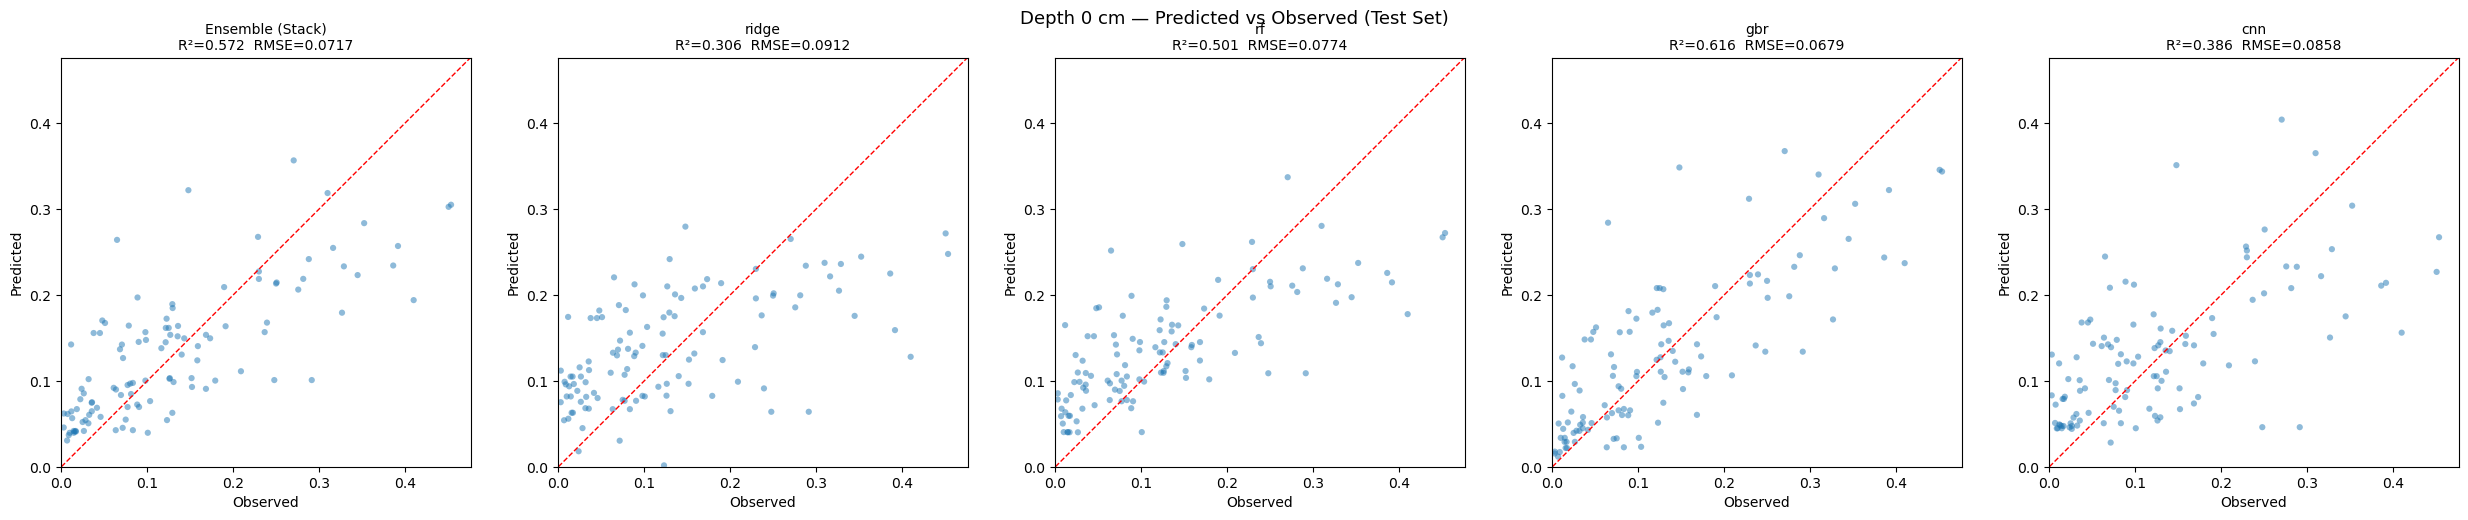

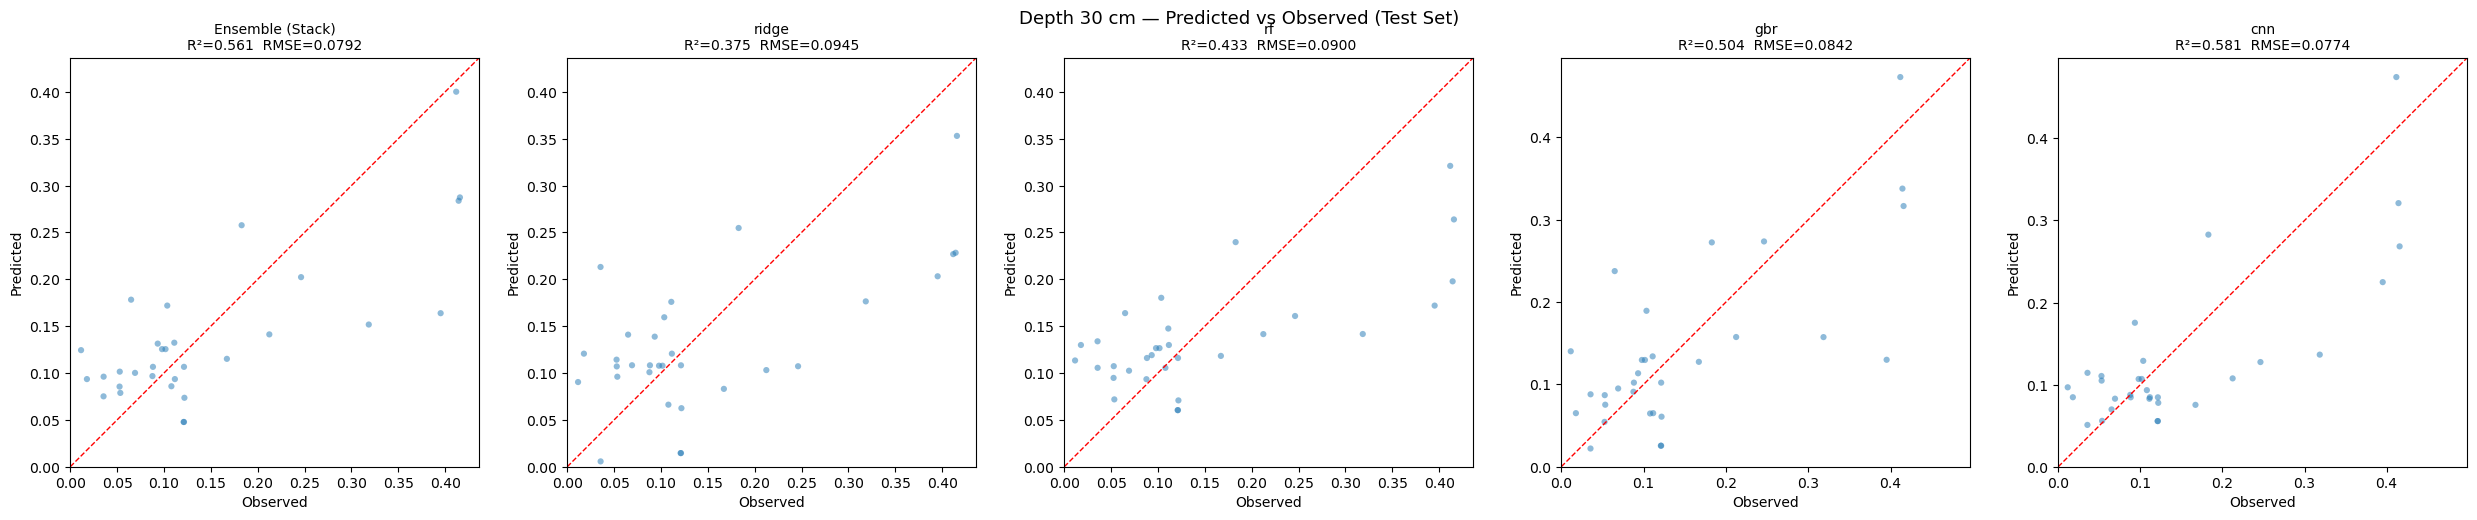

In [94]:
# predictions vs observations
for depth, res in results.items():
    test_res = res["test_results"]
    y_test = res["y_test"]
    n_models = len(test_res)

    fig, axes = plt.subplots(1, n_models, figsize=(5 * n_models, 5))
    if n_models == 1:
        axes = [axes]

    for ax, (name, m) in zip(axes, test_res.items()):
        ax.scatter(y_test, m["y_pred"], alpha=0.5, s=20, edgecolors="none")
        lims = [0, max(y_test.max(), m["y_pred"].max()) * 1.05]
        ax.plot(lims, lims, "r--", linewidth=1)
        ax.set_xlim(lims); ax.set_ylim(lims)
        ax.set_xlabel("Observed")
        ax.set_ylabel("Predicted")
        ax.set_title(f"{name}\nR²={m['r2']:.3f}  RMSE={m['rmse']:.4f}", fontsize=10)
        ax.set_aspect("equal")

    fig.suptitle(f"Depth {depth} cm - Predicted vs Observed", fontsize=13)
    plt.tight_layout()
    plt.show()

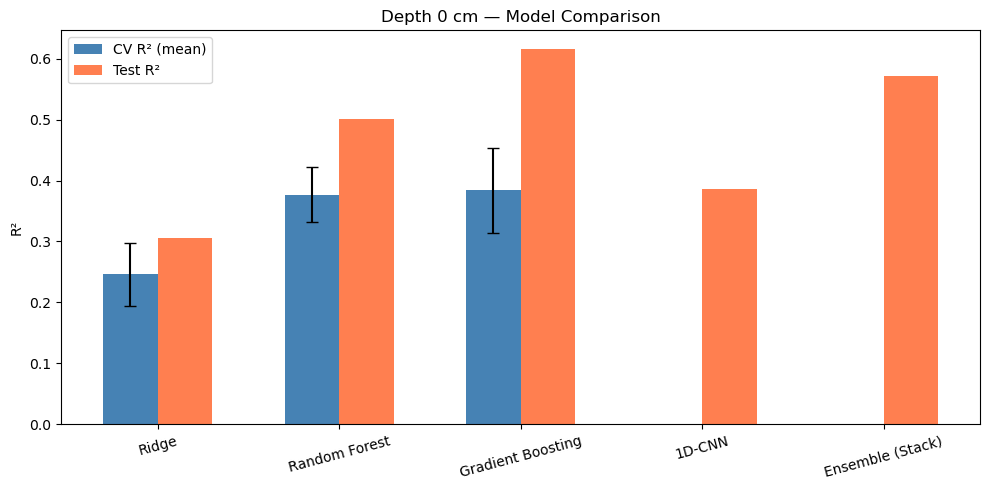

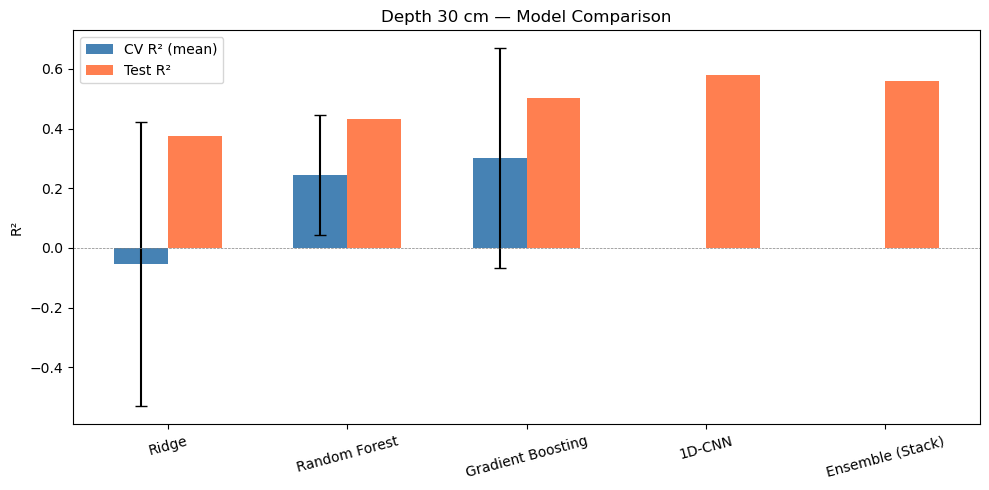

In [95]:
# r-squared comparison
for depth, res in results.items():
    cv_res = res["cv_results"]
    test_res = res["test_results"]

    model_names = list(cv_res.keys()) + ["1D-CNN", "Ensemble (Stack)"]
    cv_r2 = [cv_res[n]["r2"] for n in cv_res] + [np.nan, np.nan]
    cv_std = [cv_res[n]["r2_std"] for n in cv_res] + [0, 0]
    test_r2 = [test_res.get(n.lower().replace(" ", "_"), test_res.get(n, {})).get("r2", np.nan)
               for n in cv_res]
    # Map base model names to stacking estimator names
    name_map = {"Ridge": "ridge", "Random Forest": "rf", "Gradient Boosting": "gbr"}
    test_r2 = [test_res.get(name_map.get(n, n), {}).get("r2", np.nan) for n in cv_res]
    test_r2 += [test_res.get("cnn", {}).get("r2", np.nan),
                test_res["Ensemble (Stack)"]["r2"]]

    x = np.arange(len(model_names))
    fig, ax = plt.subplots(figsize=(10, 5))
    ax.bar(x - 0.15, cv_r2, 0.3, label="CV R² (mean)", color="steelblue",
           yerr=cv_std, capsize=4)
    ax.bar(x + 0.15, test_r2, 0.3, label="Test R²", color="coral")
    ax.set_xticks(x)
    ax.set_xticklabels(model_names, rotation=15)
    ax.set_ylabel("R²")
    ax.set_title(f"Depth {depth} cm - Model Comparison")
    ax.legend()
    ax.axhline(0, color="gray", linestyle="--", linewidth=0.5)
    plt.tight_layout()
    plt.show()

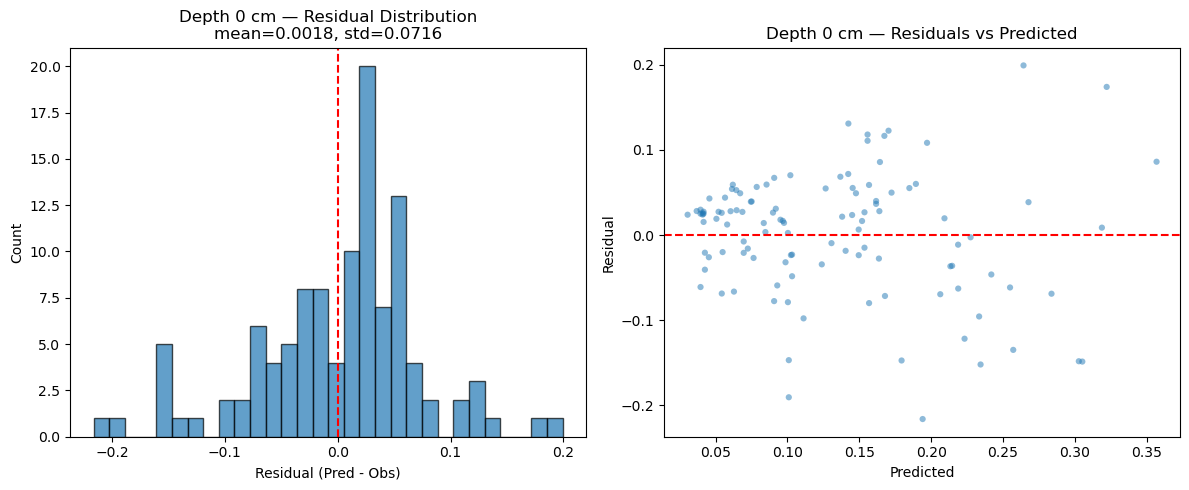

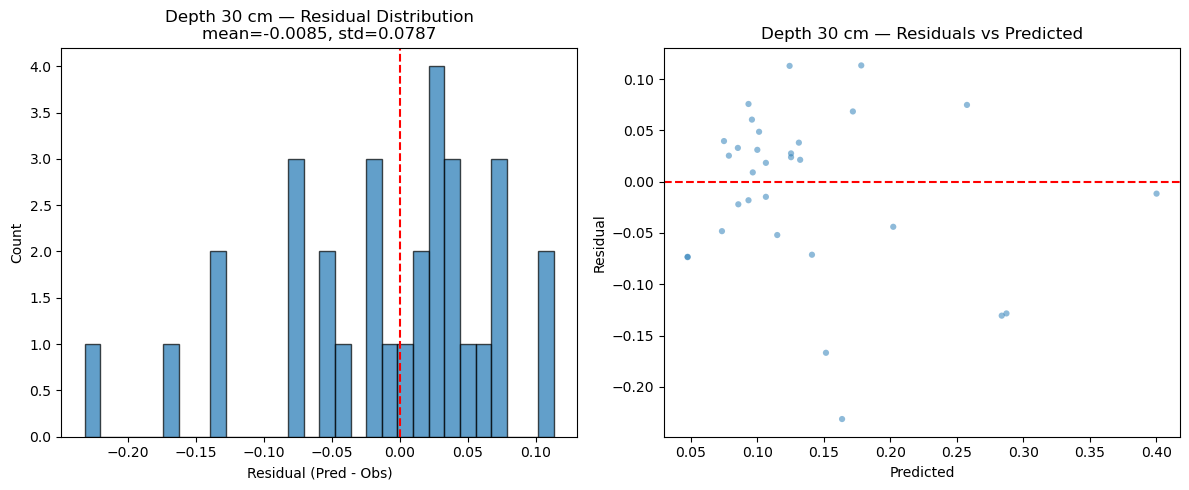

In [96]:
# residual distributions for ensemble
for depth, res in results.items():
    y_test = res["y_test"]
    y_pred = res["test_results"]["Ensemble (Stack)"]["y_pred"]
    residuals = y_pred - y_test

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

    ax1.hist(residuals, bins=30, edgecolor="black", alpha=0.7)
    ax1.axvline(0, color="red", linestyle="--")
    ax1.set_xlabel("Residual (Pred - Obs)")
    ax1.set_ylabel("Count")
    ax1.set_title(f"Depth {depth} cm - Residual Distribution\n"
                  f"mean={residuals.mean():.4f}, std={residuals.std():.4f}")

    # residual vs predicted (for heteroscedasticity)
    ax2.scatter(y_pred, residuals, alpha=0.5, s=20, edgecolors="none")
    ax2.axhline(0, color="red", linestyle="--")
    ax2.set_xlabel("Predicted")
    ax2.set_ylabel("Residual")
    ax2.set_title(f"Depth {depth} cm - Residuals vs Predicted")

    plt.tight_layout()
    plt.show()

In [97]:
# summary table
summary_rows = []
for depth, res in results.items():
    ens = res["test_results"]["Ensemble (Stack)"]
    # Find best individual model
    best_name, best_r2 = "", -999
    for name, m in res["test_results"].items():
        if name != "Ensemble (Stack)" and m["r2"] > best_r2:
            best_name, best_r2 = name, m["r2"]

    summary_rows.append({
        "Depth (cm)": depth,
        "N (train/test)": f"{res['n_train']}/{res['n_test']}",
        "Ensemble R²": round(ens["r2"], 4),
        "Ensemble MAE": round(ens["mae"], 4),
        "Ensemble RMSE": round(ens["rmse"], 4),
        "Best Base Model": best_name,
        "Best Base R²": round(best_r2, 4),
    })

summary_df = pd.DataFrame(summary_rows)
print(summary_df.to_string(index=False))

 Depth (cm) N (train/test)  Ensemble R²  Ensemble MAE  Ensemble RMSE Best Base Model  Best Base R²
          0        445/112       0.5718        0.0553         0.0717             gbr        0.6157
         30         122/31       0.5610        0.0615         0.0792             cnn        0.5810


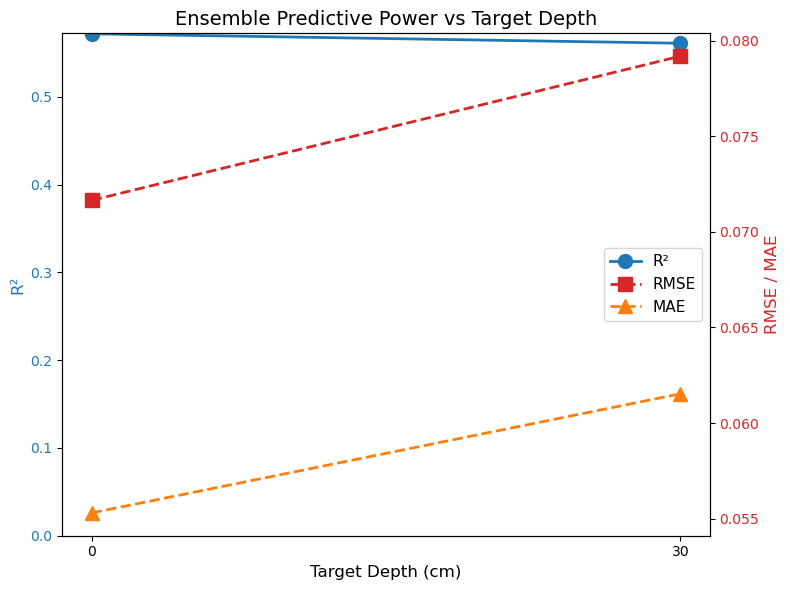

In [98]:
# ensemble R-squared and RMSE vs depth
depths = [d for d in results]
r2_vals = [results[d]["test_results"]["Ensemble (Stack)"]["r2"] for d in depths]
rmse_vals = [results[d]["test_results"]["Ensemble (Stack)"]["rmse"] for d in depths]
mae_vals = [results[d]["test_results"]["Ensemble (Stack)"]["mae"] for d in depths]

fig, ax1 = plt.subplots(figsize=(8, 6))

color_r2 = "tab:blue"
ax1.set_xlabel("Target Depth (cm)", fontsize=12)
ax1.set_ylabel("R²", color=color_r2, fontsize=12)
ax1.plot(depths, r2_vals, "o-", color=color_r2, linewidth=2, markersize=10, label="R²")
ax1.tick_params(axis="y", labelcolor=color_r2)
ax1.set_ylim(bottom=min(0, min(r2_vals) - 0.05))

ax2 = ax1.twinx()
color_rmse = "tab:red"
ax2.set_ylabel("RMSE / MAE", color=color_rmse, fontsize=12)
ax2.plot(depths, rmse_vals, "s--", color=color_rmse, linewidth=2, markersize=10, label="RMSE")
ax2.plot(depths, mae_vals, "^--", color="tab:orange", linewidth=2, markersize=10, label="MAE")
ax2.tick_params(axis="y", labelcolor=color_rmse)

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="center right", fontsize=11)

ax1.set_xticks(depths)
ax1.set_title("Ensemble Predictive Power vs Target Depth", fontsize=14)
fig.tight_layout()
plt.show()

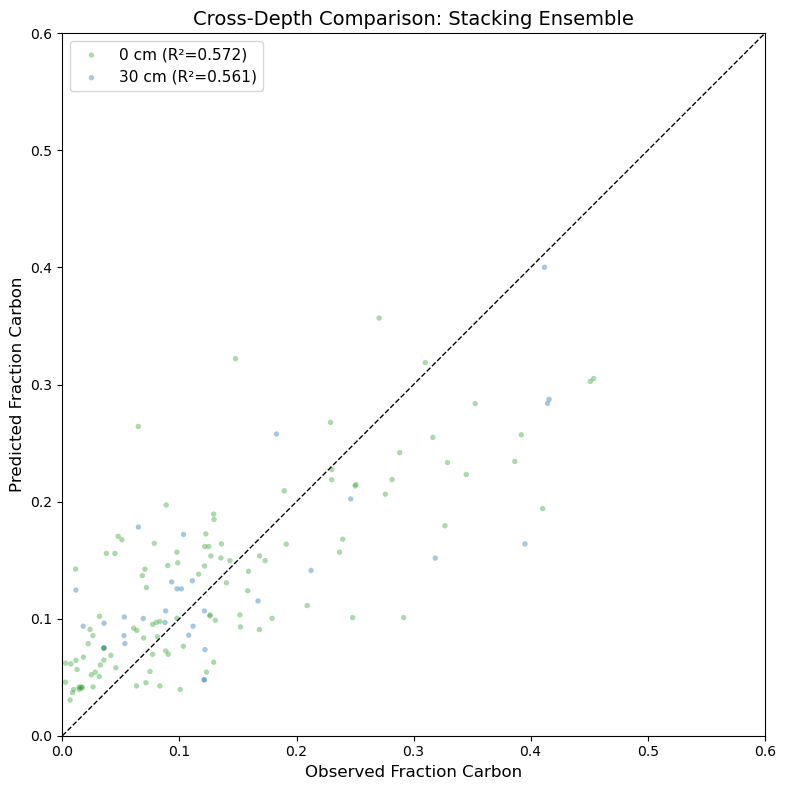

In [99]:
fig, ax = plt.subplots(figsize=(8, 8))

colors = {0: "tab:green", 30: "tab:blue", 100: "tab:red"}
for depth, res in results.items():
    ens = res["test_results"]["Ensemble (Stack)"]
    ax.scatter(res["y_test"], ens["y_pred"], alpha=0.4, s=15, edgecolors="none",
               color=colors.get(depth, "gray"),
               label=f"{depth} cm (R²={ens['r2']:.3f})")

lims = [0, 0.6]
ax.plot(lims, lims, "k--", linewidth=1)
ax.set_xlim(lims); ax.set_ylim(lims)
ax.set_xlabel("Observed Fraction Carbon", fontsize=12)
ax.set_ylabel("Predicted Fraction Carbon", fontsize=12)
ax.set_title("Depth Comparison: Stacking Ensemble", fontsize=14)
ax.set_aspect("equal")
ax.legend(fontsize=11)
plt.tight_layout()
plt.show()

## Save artifacts

In [100]:
import joblib

for depth, res in results.items():
    label = f"{depth}cm"
    # save full stacking ensemble
    joblib.dump(res["stack"], OUT_DIR / f"stack_ensemble_{label}.pkl")
    # scaler + PCA
    joblib.dump(res["scaler"], OUT_DIR / f"scaler_{label}.pkl")
    joblib.dump(res["pca"], OUT_DIR / f"pca_{label}.pkl")
    # test predictions
    ens = res["test_results"]["Ensemble (Stack)"]
    pd.DataFrame({
        "observed": res["y_test"],
        "predicted": ens["y_pred"],
    }).to_csv(OUT_DIR / f"test_predictions_{label}.csv", index=False)

# band metadata
pd.DataFrame({
    "band_name": keep_cols,
    "wavelength_nm": wavelengths_kept,
}).to_csv(OUT_DIR / "band_metadata.csv", index=False)

# summary table
summary_df.to_csv(OUT_DIR / "depth_comparison_summary.csv", index=False)

print("Saved ensembles, scalers, PCA, predictions, and comparison summary.")

Saved ensembles, scalers, PCA, predictions, and comparison summary.
